In [1]:
%load_ext autoreload
%autoreload 2

Failed to read module file 'c:\Users\Lucio\miniconda3\envs\RL\Lib\re\_casefix.py' for module 're._casefix': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Lucio\miniconda3\envs\RL\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1140, in _find_and_load_unlocked
ModuleN

In [ ]:
import os
import sys
import gymnasium as gym
import yaml
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd

sys.path.append(os.path.abspath("../envs"))
sys.path.append(os.path.abspath("../models"))
sys.path.append(os.path.abspath("../src"))

from utils_q_learning import *

In [3]:
with open("../config/q_learning_config.yaml", "r") as f:
    config = yaml.safe_load(f)

Failed to read module file 'c:\Users\Lucio\Documents\Semestre 1\Aprendizaje reforzado\TPs\RL-TP2\src\utils_q_learning.py' for module 'utils_q_learning': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 219, in update_sources
    self.source_by_modname[new_modname] = f.read()
                                          ^^^^^^^^
  File "c:\Users\Lucio\miniconda3\envs\RL\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x90 in position 8971: character maps to <undefined>


### 1)

In [4]:
experiment_folder = "parte1_1"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
alpha = config[experiment_folder]["alpha"]
gamma = config[experiment_folder]["gamma"]
epsilon = config[experiment_folder]["epsilon"]
seed = config["xtra"]["seed"]

model_1_path, _ = train_q_learning(experiment_folder, env, episodes, alpha, gamma, epsilon, seed=seed)

In [5]:
experiment_folder = "parte1_1"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)
seed = config["xtra"]["seed"]

success_rate, truncateds = evaluate_Q(model_1_path, env, episodes=100, epsilon=0.0, seed=seed)
print(f"Success rate: {success_rate:.2f} with truncateds: {truncateds:.2f}")

Success rate: 0.06 with truncateds: 0.00


### 2)

In [6]:
experiment_folder = "parte1_2"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
gamma = config[experiment_folder]["gamma"]
seed = config["xtra"]["seed"]
alphas = [0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]
epsilons = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
best_a_eps = search_hyperparameters(experiment_folder, env, episodes, gamma, alphas, epsilons, seed=seed)

Searching hyper:   0%|          | 0/88 [00:00<?, ?it/s]

Best epsilon for alpha 0.5: 0.4 with success rate 0.74
Best epsilon for alpha 0.1: 1.0 with success rate 0.76
Best epsilon for alpha 0.1: 1.0 with success rate 0.76
Best epsilon for alpha 0.05: 1.0 with success rate 0.76
Best epsilon for alpha 0.05: 1.0 with success rate 0.76
Best epsilon for alpha 0.01: 0.4 with success rate 0.76
Best epsilon for alpha 0.01: 0.4 with success rate 0.76
Best epsilon for alpha 0.005: 0.4 with success rate 0.37
Best epsilon for alpha 0.005: 0.4 with success rate 0.37
Best epsilon for alpha 0.001: 0.4 with success rate 0.25
Best epsilon for alpha 0.001: 0.4 with success rate 0.25
Best epsilon for alpha 0.0005: 0.4 with success rate 0.25
Best epsilon for alpha 0.0005: 0.4 with success rate 0.25


In [4]:
experiment_folder = "parte1_2"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
gamma = config[experiment_folder]["gamma"]
seed = config["xtra"]["seed"]
alphas = [0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]
epsilons = [0.4, 1.0, 1.0, 0.4, 0.4, 0.4, 0.4, 0.4]
results = []
over_0_7 = []

for alpha, eps in zip(alphas, epsilons):  # to save the Q
    path, _ = train_q_learning(experiment_folder, env, episodes, alpha, gamma, eps, seed=seed)
    success_rate, truncateds = evaluate_Q(path, env, episodes=100, epsilon=0.0, seed=seed)
    results.append((success_rate, alpha, eps))
    if success_rate > 0.7:
        over_0_7.append((success_rate, alpha, eps, path))

    print(f"Alpha: {alpha}, Epsilon: {eps}, Success Rate: {success_rate:.2f}, with truncateds: {truncateds:.2f}")

Experiment ../runs/q_learning/parte1_2/epi_10000_a_0.5_g_0.99_eps_0.4 already exists.
Alpha: 0.5, Epsilon: 0.4, Success Rate: 0.74, with truncateds: 4.00
Experiment ../runs/q_learning/parte1_2/epi_10000_a_0.1_g_0.99_eps_1.0 already exists.
Alpha: 0.1, Epsilon: 1.0, Success Rate: 0.76, with truncateds: 7.00
Experiment ../runs/q_learning/parte1_2/epi_10000_a_0.05_g_0.99_eps_1.0 already exists.
Alpha: 0.05, Epsilon: 1.0, Success Rate: 0.76, with truncateds: 7.00
Experiment ../runs/q_learning/parte1_2/epi_10000_a_0.01_g_0.99_eps_0.4 already exists.
Alpha: 0.01, Epsilon: 0.4, Success Rate: 0.76, with truncateds: 7.00
Experiment ../runs/q_learning/parte1_2/epi_10000_a_0.005_g_0.99_eps_0.4 already exists.
Alpha: 0.005, Epsilon: 0.4, Success Rate: 0.37, with truncateds: 0.00
Experiment ../runs/q_learning/parte1_2/epi_10000_a_0.001_g_0.99_eps_0.4 already exists.
Alpha: 0.001, Epsilon: 0.4, Success Rate: 0.25, with truncateds: 0.00
Experiment ../runs/q_learning/parte1_2/epi_10000_a_0.0005_g_0.99

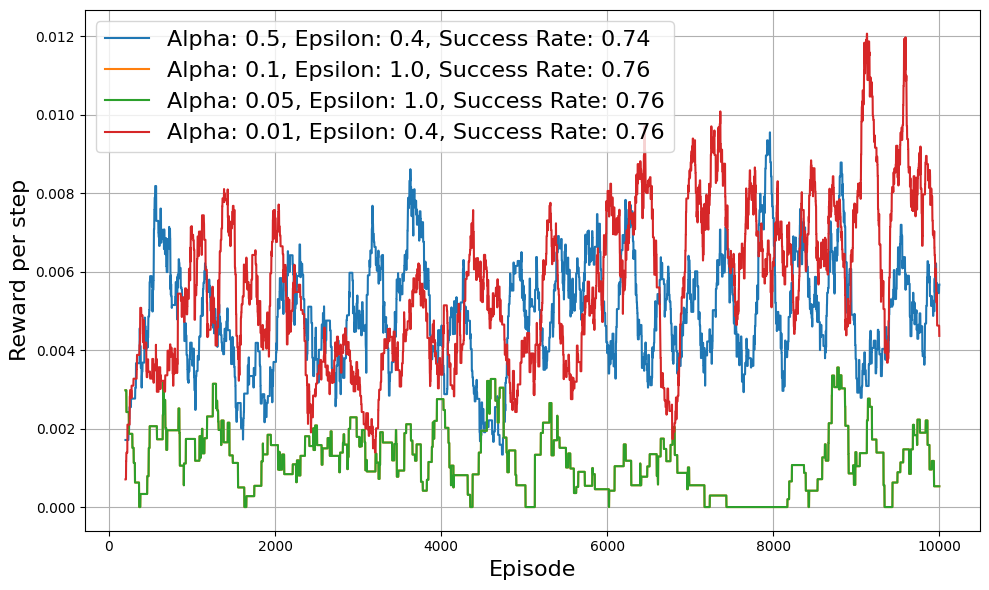

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
tag = 'Reward per step/Episode'

for success_rate, alpha, eps, path in over_0_7:
    run_path = Path(path.replace("../models/saved_models", "../runs")).with_suffix("")
    steps, values = load_from_tensorboard(run_path, tag)
    window = 200
    smoothed = pd.Series(values).rolling(window).mean().dropna()
    steps_smoothed = steps[window - 1:]

    ax.plot(steps_smoothed, smoothed, label=f"Alpha: {alpha}, Epsilon: {eps}, Success Rate: {success_rate:.2f}")
    
ax.set_xlabel("Episode", fontsize=16)
ax.set_ylabel("Reward per step", fontsize=16)
ax.legend(fontsize = 16)
ax.grid()
plt.tight_layout()
image_name = "hiperparameters_rewards"
path = Path(f"../images/{image_name}.png")
if not path.parent.exists():
    path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(path, dpi=300)
plt.show()

In [ ]:
df = pd.DataFrame(results, columns=["Success Rate", "Alpha", "Epsilon"])
df = df.sort_values("Success Rate", ascending=False).reset_index(drop=True)
df.index += 1

df["Alpha"] = df["Alpha"].map(str)
df["Epsilon"] = df["Epsilon"].map(str)
df["Success Rate"] = df["Success Rate"].map("{:.2f}".format)

df = df[["Alpha", "Epsilon", "Success Rate"]]

print(df.to_string())

    Alpha Epsilon Success Rate
1     0.1     1.0         0.76
2    0.05     1.0         0.76
3    0.01     0.4         0.76
4     0.5     0.4         0.74
5   0.005     0.4         0.37
6   0.001     0.4         0.25
7  0.0005     0.4         0.25
8  0.0001     0.4         0.25


In [8]:
experiment_folder = "parte1_2"

results_sorted = sorted(results, key=lambda x: x[0])
best_success_rate, best_alpha, best_epsilon = results_sorted[-1]
print(f"Best alpha: {best_alpha}, Best epsilon: {best_epsilon}")
config[experiment_folder]["best_alpha"] = best_alpha
config[experiment_folder]["best_epsilon"] = best_epsilon
with open("../config/q_learning_config.yaml", "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

Best alpha: 0.01, Best epsilon: 0.4


### 3)

In [ ]:
epsilons = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
experiment_folder = "parte1_2"

episodes = config[experiment_folder]["episodes"]
alpha = config[experiment_folder]["best_alpha"]
gamma = config[experiment_folder]["gamma"]

seed = config["xtra"]["seed"]
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)
succ_rates_train = []
for eps in epsilons:
    _, Q = train_q_learning(experiment_folder, env, episodes, alpha, gamma, eps, seed=seed, save = False)
    success_rate = evaluate_Q_model(Q, env, episodes=100, epsilon=0.0, seed=seed)
    print(f"Success rate for epsilon {eps}: {success_rate:.2f}")
    succ_rates_train.append(success_rate)

Success rate for epsilon 0.0: 0.00
Success rate for epsilon 0.1: 0.06
Success rate for epsilon 0.1: 0.06
Success rate for epsilon 0.2: 0.26
Success rate for epsilon 0.2: 0.26
Success rate for epsilon 0.3: 0.75
Experiment ../runs/q_learning/parte1_2/epi_10000_a_0.01_g_0.99_eps_0.4 already exists.
Success rate for epsilon 0.4: 0.76
Success rate for epsilon 0.3: 0.75
Experiment ../runs/q_learning/parte1_2/epi_10000_a_0.01_g_0.99_eps_0.4 already exists.
Success rate for epsilon 0.4: 0.76
Success rate for epsilon 0.5: 0.55
Success rate for epsilon 0.5: 0.55
Success rate for epsilon 0.6: 0.74
Success rate for epsilon 0.6: 0.74
Success rate for epsilon 0.7: 0.74
Success rate for epsilon 0.7: 0.74
Success rate for epsilon 0.8: 0.59
Success rate for epsilon 0.8: 0.59
Success rate for epsilon 0.9: 0.59
Success rate for epsilon 0.9: 0.59
Success rate for epsilon 1.0: 0.65
Success rate for epsilon 1.0: 0.65


In [10]:
experiment_folder = "parte1_2"

episodes = config[experiment_folder]["episodes"]
alpha = config[experiment_folder]["best_alpha"]
gamma = config[experiment_folder]["gamma"]
epsilon = config[experiment_folder]["best_epsilon"]

seed = config["xtra"]["seed"]
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)
model3_path, _ = train_q_learning(experiment_folder, env, episodes, alpha, gamma, epsilon, seed=seed)

Experiment ../runs/q_learning/parte1_2/epi_10000_a_0.01_g_0.99_eps_0.4 already exists.


In [11]:
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)
seed = config["xtra"]["seed"]
epsilons = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
succ_rates_eval = []
for epsilon in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    success_rate, _ = evaluate_Q(model3_path, env, episodes=100, epsilon=epsilon, seed=seed)
    succ_rates_eval.append(success_rate)
    print(f"Success rate for epsilon {epsilon}: {success_rate:.2f}")


Success rate for epsilon 0.0: 0.76
Success rate for epsilon 0.1: 0.39
Success rate for epsilon 0.2: 0.20
Success rate for epsilon 0.3: 0.14
Success rate for epsilon 0.4: 0.10
Success rate for epsilon 0.5: 0.08
Success rate for epsilon 0.6: 0.04
Success rate for epsilon 0.7: 0.02
Success rate for epsilon 0.8: 0.03
Success rate for epsilon 0.9: 0.01
Success rate for epsilon 1.0: 0.01


In [12]:
experiment_2 = "parte1_2"
experiment_folder = "parte1_4"
config[experiment_folder]["gamma"] = config[experiment_2]["gamma"]
config[experiment_folder]["alpha"] = config[experiment_2]["best_alpha"]
with open("../config/q_learning_config.yaml", "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

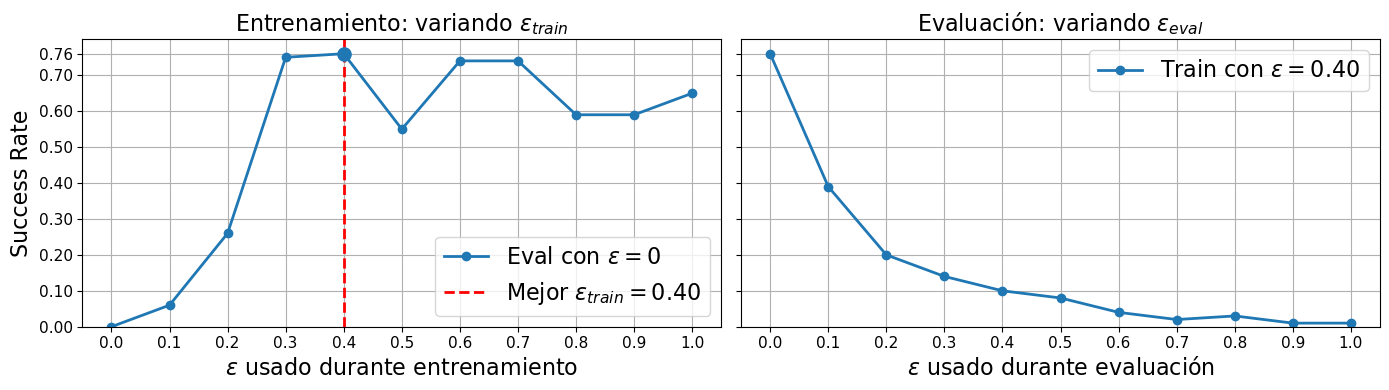

In [ ]:


epsilons = np.array(epsilons)
succ_rates_train = np.array(succ_rates_train)
succ_rates_eval = np.array(succ_rates_eval)

best_idx = np.argmax(succ_rates_train)
best_epsilon = epsilons[best_idx]
best_success_rate = succ_rates_train[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].plot(epsilons, succ_rates_train, marker="o", linewidth=2, label=r"Eval con $\epsilon=0$")
axes[0].axvline(best_epsilon, linestyle="--", color="red", linewidth=2, label=rf"Mejor $\epsilon_{{train}}={best_epsilon:.2f}$")
axes[0].scatter(best_epsilon, best_success_rate, s=90, zorder=3)
axes[0].set_title(r"Entrenamiento: variando $\epsilon_{train}$", fontsize=16)
axes[0].set_xlabel(r"$\epsilon$ usado durante entrenamiento", fontsize=16)
axes[0].set_ylabel("Success Rate", fontsize=16)
axes[0].grid(True)
axes[0].legend(fontsize=16)

axes[1].plot(epsilons, succ_rates_eval, marker="o", linewidth=2, label=rf"Train con $\epsilon={best_epsilon:.2f}$")
axes[1].set_title(r"Evaluación: variando $\epsilon_{eval}$", fontsize=16)
axes[1].set_xlabel(r"$\epsilon$ usado durante evaluación", fontsize=16)
axes[1].grid(True)
axes[1].legend(fontsize=16)

for ax in axes:
    ax.set_xticks(epsilons)
    ax.tick_params(axis="both", labelsize=11)

yticks = list(np.arange(0.0, 0.71, 0.1)) + [0.76]
axes[0].set_ylim(0.0, 0.8)
axes[0].set_yticks(yticks)

plt.tight_layout()

path = Path("../images/success_rate_epsilon_comparison.png")
if not os.path.exists(path.parent):
    os.makedirs(path.parent)
plt.savefig(path, dpi=300, bbox_inches="tight")

plt.show()

### 4)

In [ ]:
experiment_folder = "parte1_4"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
gamma = config[experiment_folder]["gamma"]
alpha = config[experiment_folder]["alpha"]
seed = config["xtra"]["seed"]
min_epsilons = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9]
max_epsilons = [0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 1.0]
decays_rate = [0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 1.0]
best_max_decay, global_best = search_eps_decay(experiment_folder, env, episodes, gamma, alpha, min_epsilons, max_epsilons, decays_rate, seed)

Total hyperparameter combinations to evaluate: 252


Searching hyper:   0%|          | 0/252 [00:00<?, ?it/s]

In [ ]:
matching_best_max_decay = sorted(
    (
        (min_epsilon, values[0], values[1], values[2])
        for min_epsilon, values in best_max_decay.items()
        if values is not None and np.isclose(values[2], global_best["success_rate"])
    ),
    key=lambda item: item[3],
    reverse=True,
)

print(f"Combinations matching global best success rate ({global_best['success_rate']:.2f}):")
for min_epsilon, max_epsilon, decay_rate, success_rate in matching_best_max_decay:
    print(
        f"min_epsilon={min_epsilon}, max_epsilon={max_epsilon}, "
        f"decay_rate={decay_rate}, success_rate={success_rate:.2f}"
    )

Combinations matching global best success rate (0.76):
min_epsilon=0.1, max_epsilon=0.9, decay_rate=0.2, success_rate=0.76
min_epsilon=0.2, max_epsilon=0.8, decay_rate=0.01, success_rate=0.76
min_epsilon=0.4, max_epsilon=0.8, decay_rate=0.8, success_rate=0.76
min_epsilon=0.6, max_epsilon=0.8, decay_rate=0.2, success_rate=0.76


In [18]:
best_combination = matching_best_max_decay[0]
best_epsilon = best_combination[0]
best_max_epsilon = best_combination[1]
best_decay_rate = best_combination[2]
print(f"Best combination: min_epsilon={best_epsilon}, max_epsilon={best_max_epsilon}, decay_rate={best_decay_rate}")

Best combination: min_epsilon=0.1, max_epsilon=0.9, decay_rate=0.2


In [ ]:
experiment_4 = "parte1_4"
experiment_folder = "parte1_5"
config[experiment_folder]["gamma"] = config[experiment_4]["gamma"]
config[experiment_folder]["alpha"] = config[experiment_4]["alpha"]
config[experiment_folder]["min_epsilon"] = best_epsilon
config[experiment_folder]["max_epsilon"] = best_max_epsilon
config[experiment_folder]["decay_rate"] = best_decay_rate

with open("../config/q_learning_config.yaml", "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

### 5)

In [4]:
experiment_folder = "parte1_5"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
alpha = config[experiment_folder]["alpha"]
gamma = config[experiment_folder]["gamma"]
min_epsilon = config[experiment_folder]["min_epsilon"]
max_epsilon = config[experiment_folder]["max_epsilon"]
decay_rate = config[experiment_folder]["decay_rate"]
seed = config["xtra"]["seed"]

model_5_path, Q = train_q_learning(experiment_folder, env, episodes, alpha, gamma, min_epsilon, max_epsilon, decay_rate, seed=seed)

Experiment ../runs/q_learning/parte1_5/epi_10000_a_0.01_g_0.99_eps_0.1_max_eps_0.9_decay_0.2 already exists.


Failed to read module file 'c:\Users\Lucio\Documents\Semestre 1\Aprendizaje reforzado\TPs\RL-TP2\src\utils_q_learning.py' for module 'utils_q_learning': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 556, in maybe_reload_module
    new_source_code = f.read()
                      ^^^^^^^^
  File "c:\Users\Lucio\miniconda3\envs\RL\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x90 in position 8971: character maps to <undefined>


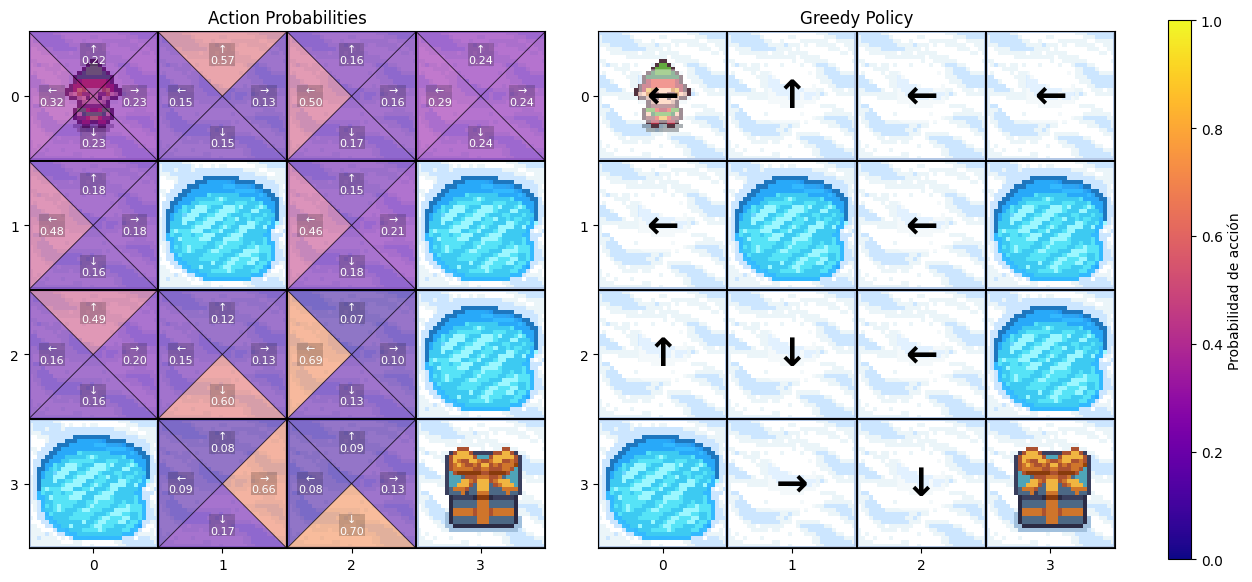

In [7]:
plot_frozenlake_policy_comparison(Q, temperature=0.2, save_path="../images/Q_frozen_lake.png", policy_alpha=0.55)

In [23]:
experiment_folder = "parte1_5"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)
seed = config["xtra"]["seed"]

success_rate, truncateds = evaluate_Q(model_5_path, env, episodes=100, epsilon=0.0, seed=seed)
print(f"Success rate: {success_rate:.2f}")
print(f"Truncated episodes: {truncateds}")

Success rate: 0.76
Truncated episodes: 7


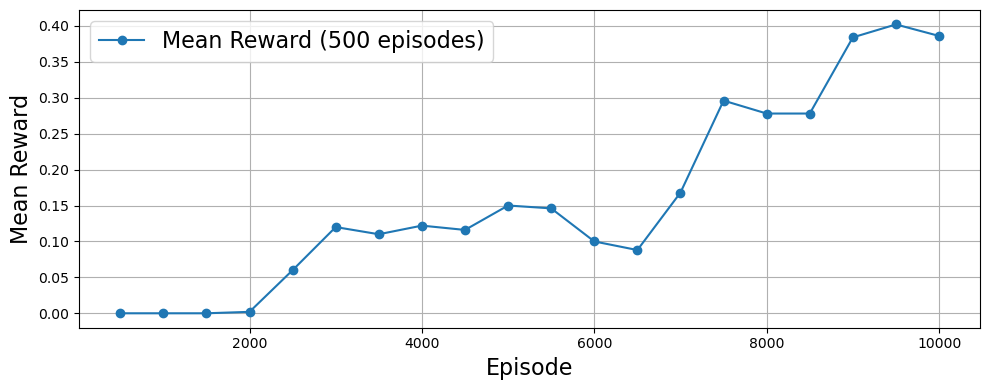

In [24]:
folder_name = "q_learning/parte1_5"
window = 500
path = "../images/mean_rewards.png"
plot_mean_rewards(folder_name, path, window)

### 6)

In [25]:
experiment_folder = "parte1_5"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
alpha = config[experiment_folder]["alpha"]
gamma = config[experiment_folder]["gamma"]
min_epsilon = config[experiment_folder]["min_epsilon"]
max_epsilon = config[experiment_folder]["max_epsilon"]
decay_rate = config[experiment_folder]["decay_rate"]
seed = config["xtra"]["seed"]

model_5_path, _ = train_q_learning(experiment_folder, env, episodes, alpha, gamma, min_epsilon, max_epsilon, decay_rate, seed=seed)

Experiment ../runs/q_learning/parte1_5/epi_10000_a_0.01_g_0.99_eps_0.1_max_eps_0.9_decay_0.2 already exists.


In [26]:
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = "rgb_array")
experiment_name = "Frozen_lake_video"
num_episodes = 1
epsilon = 0.0
seed = config["xtra"]["seed"]

record_experiment(model_5_path, experiment_name, env, num_episodes, epsilon, seed)

Episode 1 | Total reward: 1


/home/alumno1/miniconda3/envs/vision/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/alumno1/Documents/RL-TP2/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
